In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
pwd

'e:\\Quan\\AutoRoboticInspection-V1\\VIKO_UltraRobot\\library\\experimental_src'

In [1]:
import plotly.express as px
from PIL import Image

# Load the image
image_path = '../../laser/image_2024-07-27_15-37-20_2000l-5000e-3900i.jpg'
image = Image.open(image_path)

# Display the image using Plotly Express
fig = px.imshow(image)
fig.show()


In [2]:
import cv2
image = cv2.imread(image_path, cv2.IMREAD_COLOR)
img_rs = cv2.resize(image, (2448, 2048), cv2.INTER_CUBIC)

In [3]:
fig = px.imshow(img_rs)
fig.show()

In [2]:

import sys
sys.path.append(
    "E:\\Quan\\AutoRoboticInspection\VIKO_UltraRobot"
)

from library import vision_robotic as vis
from ultralytics import YOLO
from config import config as CFG
import cv2

In [10]:
pwd

'e:\\Quan\\AutoRoboticInspection-v1\\VIKO_UltraRobot\\src'

In [5]:
%cd ..

e:\Quan\AutoRoboticInspection-v1\VIKO_UltraRobot


In [3]:
model  = YOLO(CFG.MODEL['YOLOV9']['WEIGHT'])

In [6]:
img =  cv2.imread('data/AI/Record_2024-05-07/20240507-104449393442-acA2440-35uc_22481496.png')

In [25]:
img.shape

(2048, 2448, 3)

In [11]:
model  = YOLO(CFG.MODEL['YOLOV9']['WEIGHT'])
img = cv2.resize(img, (640, 640), interpolation=cv2.INTER_CUBIC)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model.predict(source=img, conf=0.65)
# vis.getCoordinates(model, img)


0: 640x640 1 0_degree, 39.9ms
Speed: 2.0ms preprocess, 39.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [27]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: '0_degree', 1: 'weld', 2: '90_degree', 3: 'other', 4: '30_degree'}
 obb: None
 orig_img: array([[[166, 188, 187],
         [158, 190, 191],
         [162, 186, 194],
         ...,
         [172, 205, 208],
         [169, 202, 215],
         [170, 198, 213]],
 
        [[160, 190, 191],
         [162, 186, 197],
         [163, 189, 189],
         ...,
         [166, 202, 211],
         [171, 203, 208],
         [171, 199, 214]],
 
        [[161, 186, 194],
         [161, 188, 193],
         [165, 186, 195],
         ...,
         [173, 197, 213],
         [168, 197, 216],
         [168, 198, 211]],
 
        ...,
 
        [[157, 186, 190],
         [158, 183, 194],
         [164, 180, 195],
         ...,
         [161, 186, 193],
         [156, 187, 196],
         [159, 187, 191]],
 
        [[159, 185

In [3]:
data = np.loadtxt('../laser/datascan-python_2024-07-16_15-36-35.txt')

In [4]:
Z_filtered = data.copy()

(640, 640, 3)


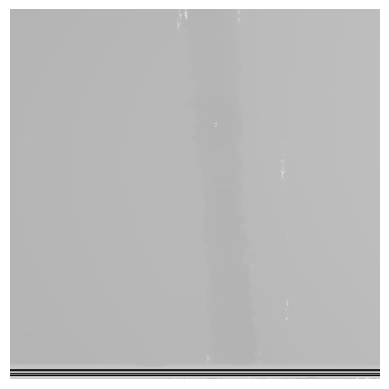

In [5]:
min_val = np.min(Z_filtered)
max_val = np.max(Z_filtered)

# Chuẩn hóa Z_filtered về khoảng [0, 1]
normalized_Z = (Z_filtered - min_val) / (max_val - min_val)

# Chuyển đổi thành màu gray scale (RGB giống nhau)
gray_image = np.stack((normalized_Z, normalized_Z, normalized_Z), axis=-1)

import cv2
gray_image = cv2.resize(gray_image, (640, 640), cv2.INTER_CUBIC)
print(gray_image.shape)
# Hiển thị mảng numpy dưới dạng heightmap
plt.imshow(gray_image)
plt.axis('off')  # Tắt trục để hiển thị màu xám
plt.show()

In [11]:
Z_filtered.shape

(2000, 2048)

In [30]:
image_rgb = (gray_image * 255).astype(np.uint8)  # Chuyển đổi về đơn vị 0-255 và kiểu dữ liệu uint8
image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB) 

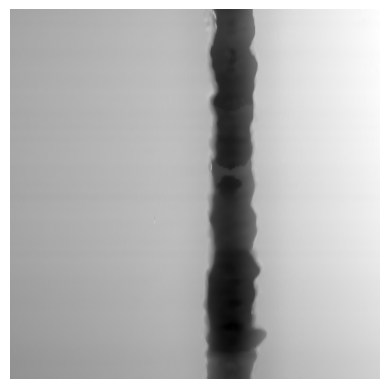

In [32]:
plt.imshow(image_rgb)
plt.axis('off')  # Tắt trục để hiển thị màu xám
plt.show()

In [ ]:
import IPCDataMs as ipc_data


data = []
filepath = 'laser/datascan.txt'
with open(filepath, 'r') as file:
    for line in file:
        row = list(map(float, line.split()))
        data.append(row)
print("3D shared memory is updated")
ipc_data.send_3Ddata(data)

In [1]:
pwd

'e:\\Quan\\AutoRoboticInspection-V1\\VIKO_UltraRobot\\library\\experimental_src'

In [127]:
# test laser

import numpy as np

# Đọc dữ liệu từ file
file_path = '../../Lidar_data.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()


# Loại bỏ các dòng trống và khoảng trắng thừa
lines = [line.strip() for line in lines if line.strip()]

# Lấy giá trị thứ hai từ mỗi dòng
values = []
for line in lines:
    try:
        second_value = float(line.split(',')[1].strip())
        values.append(second_value)
    except ValueError as e:
        print(f"Error converting line: {line}")
        raise e

# Chuyển đổi danh sách thành ma trận với số cột là 10
columns = 1024
rows = len(values) // columns
matrix = [values[i * columns:(i + 1) * columns] for i in range(rows)]

laser = np.array(matrix)





In [128]:
laser.shape

(1664, 1024)

In [129]:
non_zero_values = laser[laser != 0]
mean_value = np.mean(non_zero_values)

# Thay thế các giá trị 0 bằng giá trị trung bình
laser[laser == 0] = mean_value

In [130]:
np.min(laser)

145.126

In [131]:
import cv2
from scipy.ndimage import median_filter
# Z_filtered = laser[~np.any((laser == 0) | (laser > 36000), axis=1)]
# Z_inverted = np.flipud(laser)
Z_processed = median_filter(laser, size=3)


min_val = np.min(Z_processed)
max_val = np.max(Z_processed)

normalized_Z = (Z_processed - min_val) / (max_val - min_val)
gray_image = np.stack((normalized_Z), axis=-1)
gray_image = cv2.resize(gray_image, (640, 640), cv2.INTER_CUBIC)
image_rgb = (gray_image * 255).astype(np.uint8)
image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB)

In [132]:
max_val

149.11

In [133]:
# def apply_shading(self, image_rgb, current_time):
grad_x, grad_y, _ = np.gradient(image_rgb)
slope = np.pi / 2. - np.arctan(np.sqrt(grad_x ** 2 + grad_y ** 2))
aspect = np.arctan2(-grad_y, grad_x)
azimuth = 315  # angle between the light source and north, in degrees
altitude = 45

azimuth_rad = np.radians(azimuth)
altitude_rad = np.radians(altitude)

shaded = (np.sin(altitude_rad) * np.sin(slope) +
            np.cos(altitude_rad) * np.cos(slope) * np.cos(azimuth_rad - np.pi / 2. - aspect))

shaded = (shaded - shaded.min()) / (shaded.max() - shaded.min())
img_shaded = (shaded * 255).astype(np.uint8)
image_rgb_shaded = cv2.cvtColor(img_shaded, cv2.COLOR_BGR2RGB)

    # return image_rgb_shaded


In [134]:
from PIL import Image
image = Image.fromarray(image_rgb_shaded)
image.show()

In [135]:
cv2.imwrite('../../src/laser/TranferData/data/2.png', image_rgb)

True